# Hotel Booking Cancellations — Exploratory Data Analysis

**Author:** hotel-ml project · **Stage:** 2 (EDA) · **Data:** `data/processed/train.csv` (train split only)

---

## Why this notebook reads *only* the training split

Every chart, statistic, and insight below is computed on the **training set**. The test
set is sealed until final model evaluation. Looking at the test set during exploration —
even informally — biases every downstream decision (which features to keep, how to
transform them) toward patterns that happen to exist in the test data. That is *data
snooping*, and it makes the eventual test score dishonest. So: train only, throughout.

## What this notebook covers

1. Setup, data load, and a first structural look
2. Data quality audit (missingness, dtypes, sanity checks)
3. The target variable — cancellation rate and class balance
4. Univariate analysis — every numeric and categorical feature, one at a time
5. Bivariate analysis — each feature *versus the target*
6. Multivariate analysis — correlations, interactions, and redundancy
7. Temporal & seasonal patterns
8. Outlier deep-dive
9. Systematic leakage hunt
10. Segment profiling — *who* cancels
11. Insight summary → decisions that drive feature engineering (Stage 3)

Each section states the **question** it answers and ends with the **decision** it drives.

## 1. Setup, data load & first look

**Question:** what are we working with — shape, columns, types, first rows?

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Global aesthetics — a clean, consistent look across every chart.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 100

# A consistent two-colour scheme for the binary target throughout.
PALETTE = {0: "#2a78d6", 1: "#d95926"}   # 0 = stayed (blue), 1 = canceled (orange)
ACCENT = "#0f6f6f"

TARGET = "is_canceled"
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)

In [2]:
df = pd.read_csv("../data/processed/train.csv")
print(f"Training rows: {len(df):,}")
print(f"Columns:       {df.shape[1]}")
df.head()

Training rows: 96,491
Columns:       21


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,adults,children,babies,market_segment,deposit_type,customer_type,adr,previous_cancellations,booking_changes,total_of_special_requests,is_repeated_guest,country,agent,company,agent_missing,company_missing
0,City Hotel,0,183,2016,August,2,0,0,Online TA,No Deposit,Transient,174.73,0,0,0,0,RUS,238.0,0.0,0,1
1,City Hotel,0,48,2016,March,1,0,0,Online TA,Non Refund,Transient,131.79,0,0,0,0,DEU,11.0,0.0,0,1
2,City Hotel,1,232,2016,August,2,0,0,Direct,No Deposit,Transient,101.35,0,0,0,0,IRL,189.0,0.0,0,1
3,Resort Hotel,0,14,2015,February,2,0,0,Online TA,No Deposit,Transient-Party,111.72,0,0,0,0,GBR,54.0,0.0,0,1
4,City Hotel,0,286,2016,November,2,0,0,Groups,No Deposit,Group,148.88,0,1,1,0,AUT,118.0,0.0,0,1


In [3]:
# Structural overview: dtypes and non-null counts in one view.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96491 entries, 0 to 96490
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   hotel                      96491 non-null  str    
 1   is_canceled                96491 non-null  int64  
 2   lead_time                  96491 non-null  int64  
 3   arrival_date_year          96491 non-null  int64  
 4   arrival_date_month         96491 non-null  str    
 5   adults                     96491 non-null  int64  
 6   children                   96491 non-null  int64  
 7   babies                     96491 non-null  int64  
 8   market_segment             96491 non-null  str    
 9   deposit_type               96491 non-null  str    
 10  customer_type              96491 non-null  str    
 11  adr                        96491 non-null  float64
 12  previous_cancellations     96491 non-null  int64  
 13  booking_changes            96491 non-null  int64  
 14  t

**Reading `.info()`:** confirms row count, column dtypes, and where nulls remain. After
Stage 1 structural cleaning, we expect only `country` to still hold a few missing values
(imputed post-split in the pipeline). Everything else should be complete.

## 2. Data quality audit

**Question:** how clean is the data really — what's missing, what's constant, what's
duplicated? A model is only as trustworthy as the data underneath it.

In [4]:
# --- Missingness table + heatmap ---
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(3)
missing_report = pd.DataFrame({"n_missing": miss, "pct_missing": miss_pct})
print("Columns with missing values:")
print(missing_report if len(missing_report) else "  (none)")

Columns with missing values:
         n_missing  pct_missing
country        382        0.396


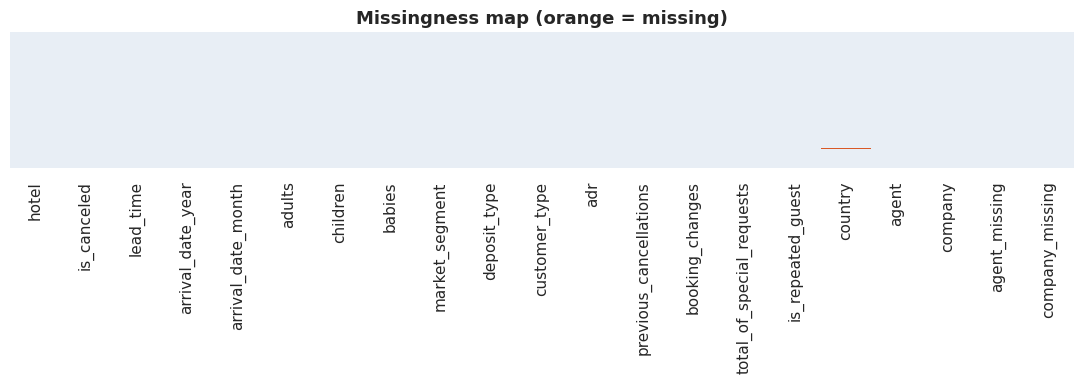

In [5]:
# Visual missingness map — a quick way to spot structure in what's absent.
plt.figure(figsize=(11, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap=["#e8eef5", "#d95926"])
plt.title("Missingness map (orange = missing)")
plt.tight_layout()
plt.show()

In [6]:
# --- Cardinality & constant-column check ---
card = df.nunique().sort_values(ascending=False)
print("Cardinality (unique values) per column:")
print(card.to_string())

constants = card[card <= 1]
print("\nConstant/near-constant columns:",
      list(constants.index) if len(constants) else "none")

Cardinality (unique values) per column:
adr                          18275
lead_time                      549
company                        350
agent                          330
country                         20
arrival_date_month              12
market_segment                   7
total_of_special_requests        5
customer_type                    4
booking_changes                  4
previous_cancellations           4
children                         4
adults                           4
deposit_type                     3
babies                           3
arrival_date_year                3
hotel                            2
is_canceled                      2
is_repeated_guest                2
agent_missing                    2
company_missing                  2

Constant/near-constant columns: none


**Decision drivers from the audit:**
- Only `country` retains missingness (a small fraction) → confirms Stage-1 discipline held;
  it's imputed with the *train* mode downstream, plus a `country_missing` flag.
- High-cardinality columns (`country`, `agent`, `company`) will need careful encoding in
  Stage 3 — naive one-hot would explode dimensionality.
- No constant columns → nothing to drop for zero variance.

## 3. The target variable — `is_canceled`

**Question:** how (im)balanced is the target? This single fact drives our choice of
evaluation metric and whether we need imbalance handling.

Stayed   (0):  64,626  (67.0%)
Canceled (1):  31,865  (33.0%)

Imbalance ratio: 2.03 : 1  (majority : minority)


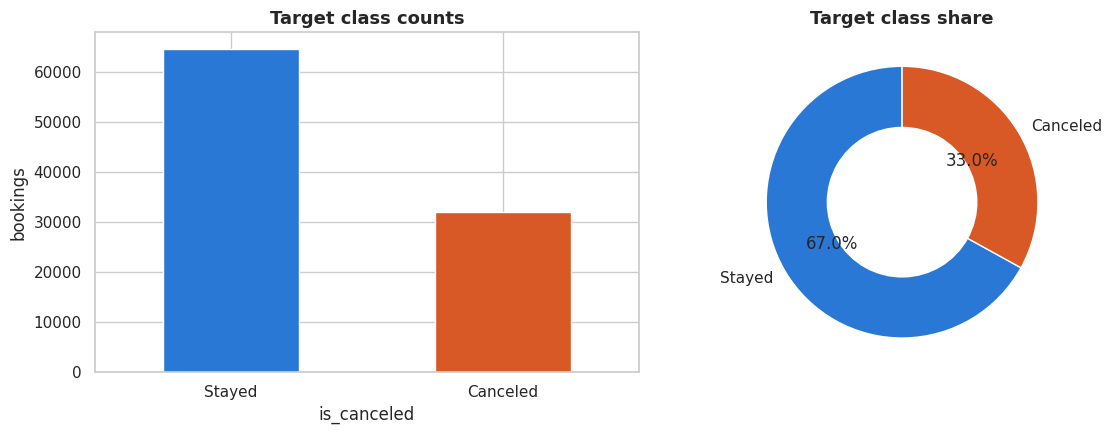

In [7]:
rate = df[TARGET].mean()
counts = df[TARGET].value_counts().sort_index()
print(f"Stayed   (0): {counts[0]:>7,}  ({(1-rate)*100:.1f}%)")
print(f"Canceled (1): {counts[1]:>7,}  ({rate*100:.1f}%)")
print(f"\nImbalance ratio: {(1-rate)/rate:.2f} : 1  (majority : minority)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
counts.plot(kind="bar", color=[PALETTE[0], PALETTE[1]], ax=ax[0])
ax[0].set_title("Target class counts")
ax[0].set_xticklabels(["Stayed", "Canceled"], rotation=0)
ax[0].set_ylabel("bookings")
ax[1].pie(counts, labels=["Stayed", "Canceled"], autopct="%1.1f%%",
          colors=[PALETTE[0], PALETTE[1]], startangle=90, wedgeprops={"width": 0.45})
ax[1].set_title("Target class share")
plt.tight_layout()
plt.show()

**Insight → Decision:** the target is imbalanced roughly **2:1**. Consequences we carry
forward:
- **Metric:** report **PR-AUC** and the precision/recall tradeoff, *not* raw accuracy — a
  model predicting "never cancel" would score ~67% accuracy while being useless.
- **Imbalance handling:** plan for class weights (and evaluate SMOTE) in the modelling
  stage.

## 4. Univariate analysis — one feature at a time

**Question:** what is the shape of each feature *in isolation*? Distribution shape decides
transforms (log for skew), scaling strategy, and reveals data-entry oddities.

We split into **numeric** and **categorical** and treat each group appropriately.

In [8]:
numeric_cols = ["lead_time", "adr", "adults", "children", "babies",
                "previous_cancellations", "booking_changes",
                "total_of_special_requests"]
categorical_cols = ["hotel", "arrival_date_month", "market_segment",
                    "deposit_type", "customer_type", "is_repeated_guest"]

# Full numeric summary including skew and kurtosis — the shape fingerprints.
summary = df[numeric_cols].describe(percentiles=[.25, .5, .75, .95, .99]).T
summary["skew"] = df[numeric_cols].skew()
summary["kurtosis"] = df[numeric_cols].kurtosis()
summary.round(2)

,count,mean,std,min,25%,50%,75%,95%,99%,max,skew,kurtosis
lead_time,96491.0,103.43,73.57,0.0,49.00,87.00,140.00,246.00,344.00,737.0,1.42,3.08
adr,96491.0,113.64,39.78,0.0,86.12,112.94,140.41,180.25,207.41,1000.0,0.21,2.42
adults,96491.0,1.90,0.58,1.0,2.00,2.00,2.00,3.00,4.00,4.0,0.64,2.59
children,96491.0,0.12,0.43,0.0,0.00,0.00,0.00,1.00,2.00,3.0,4.13,17.99
babies,96491.0,0.01,0.11,0.0,0.00,0.00,0.00,0.00,1.00,2.0,11.29,141.86
previous_cancellations,96491.0,0.09,0.38,0.0,0.00,0.00,0.00,1.00,2.00,3.0,5.03,27.69
booking_changes,96491.0,0.22,0.58,0.0,0.00,0.00,0.00,2.00,3.00,3.0,2.99,9.00
total_of_special_requests,96491.0,0.64,0.90,0.0,0.00,0.00,1.00,2.00,4.00,4.0,1.43,1.58


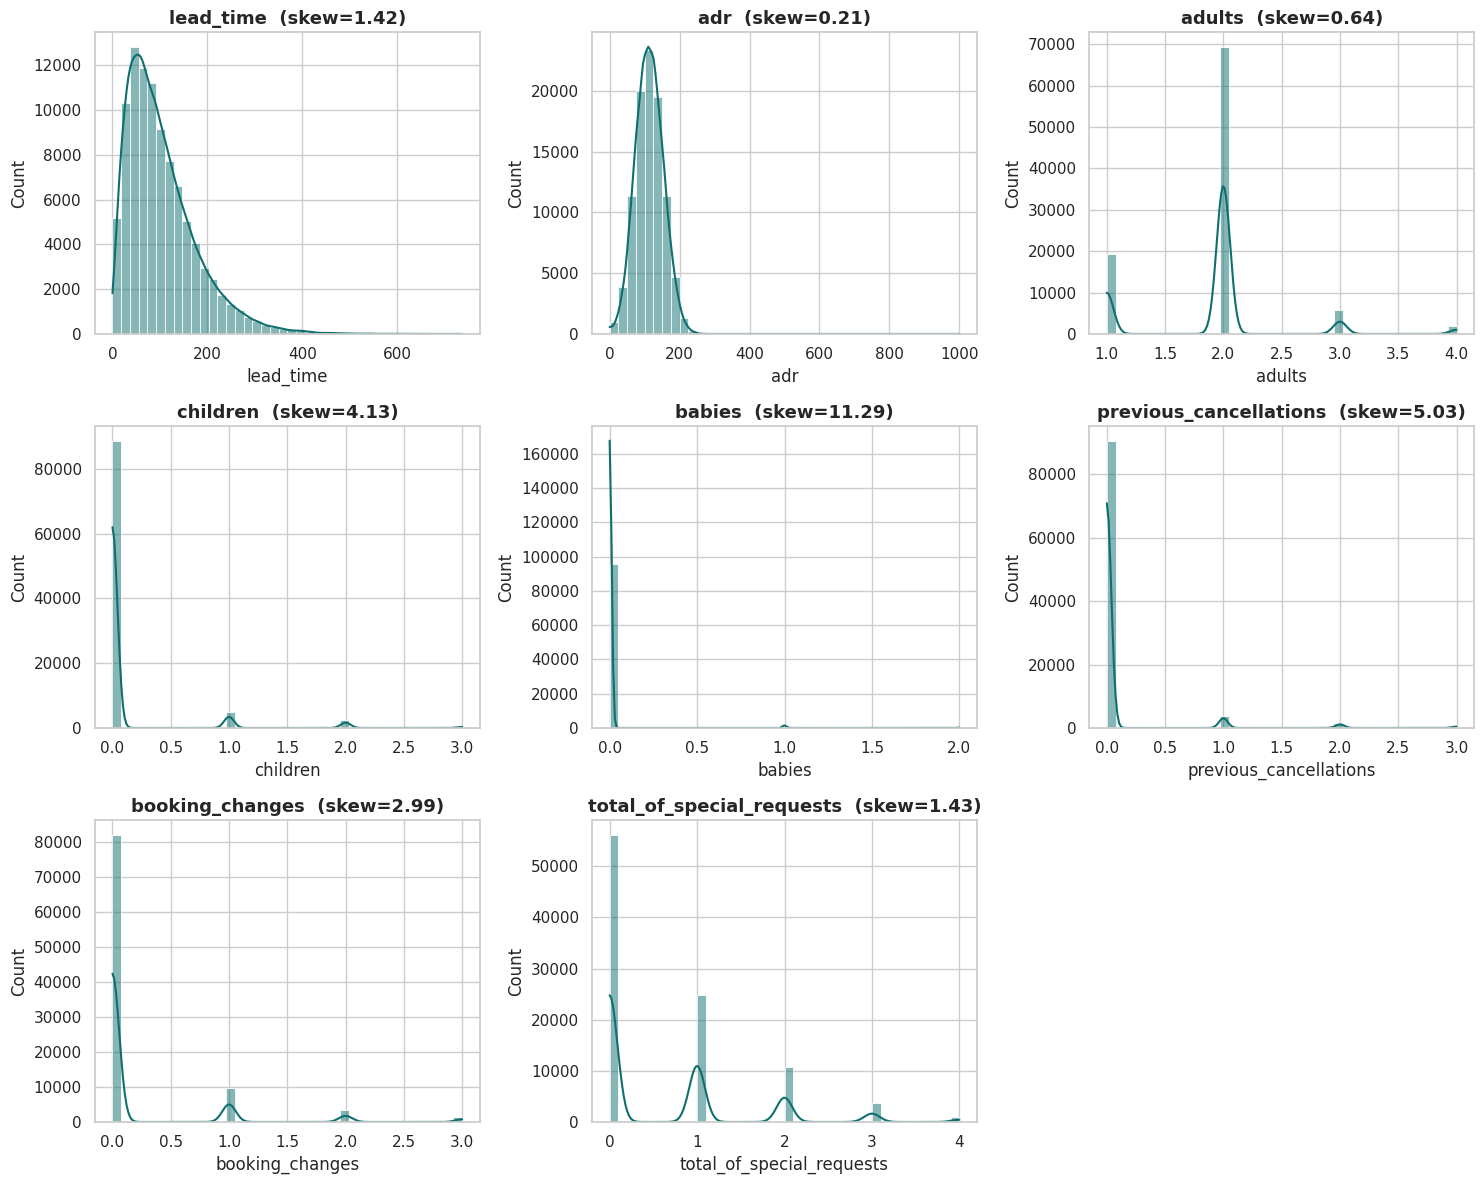

In [9]:
# Numeric distributions — histogram + KDE for each, in a grid.
n = len(numeric_cols)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(15, 4 * ((n + 2) // 3)))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col], kde=True, color=ACCENT, ax=ax, bins=40)
    ax.set_title(f"{col}  (skew={df[col].skew():.2f})")
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

**Reading the numeric distributions:**
- `lead_time` is strongly **right-skewed** (long tail of far-in-advance bookings) → a
  **log or sqrt transform** will likely help linear models and stabilise variance.
- `adr` is roughly bell-shaped after Stage-1 capping, with a tight spread → standard
  scaling is fine.
- `previous_cancellations`, `booking_changes`, `babies` are **heavily zero-inflated** →
  consider binary "has any" flags rather than raw counts.

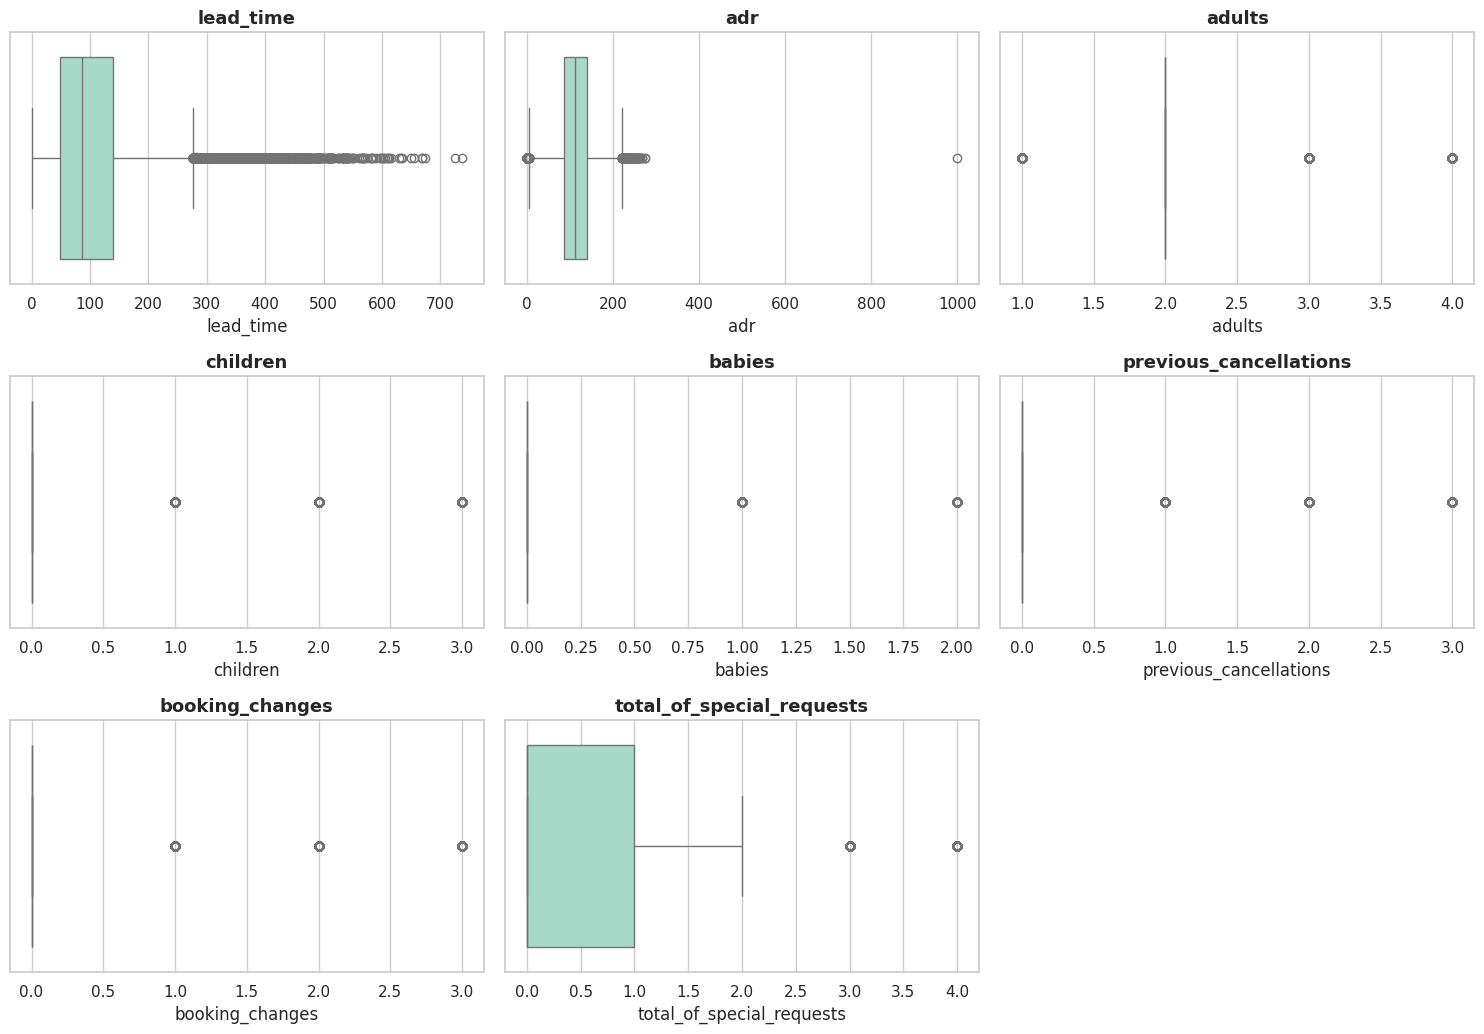

In [10]:
# Boxplots expose spread & outliers per numeric feature compactly.
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(15, 3.5 * ((n + 2) // 3)))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(x=df[col], color="#9fe1cb", ax=ax)
    ax.set_title(col)
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

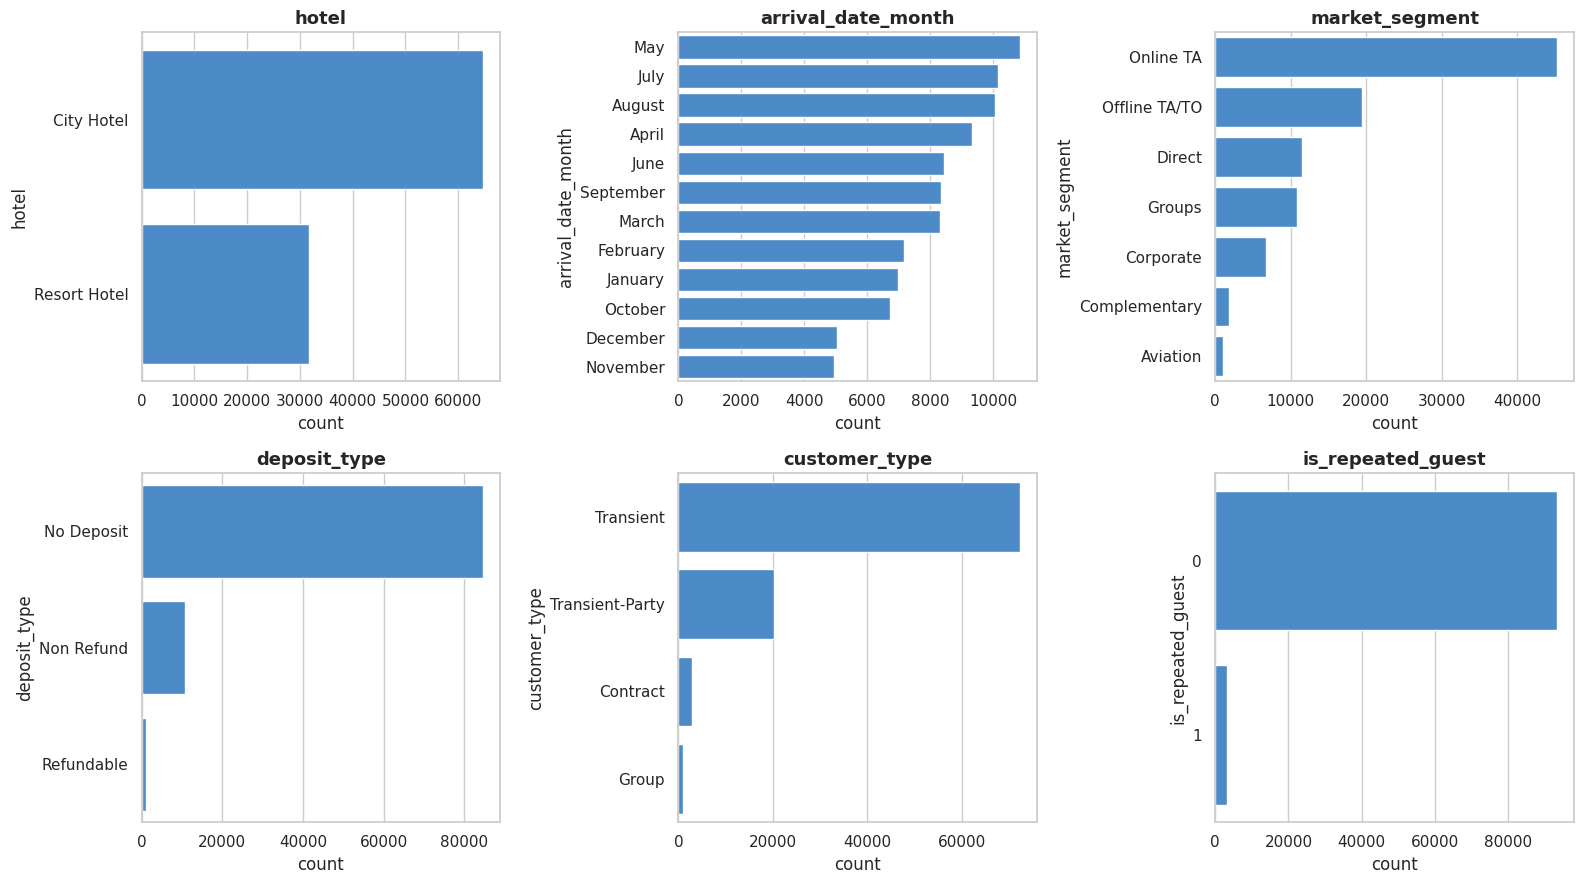

In [11]:
# Categorical frequencies — how common is each level?
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, color="#378add", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("count")
plt.tight_layout()
plt.show()

**Reading the categorical frequencies:** most bookings are City-hotel, Online-TA,
No-Deposit, Transient customers, concentrated in summer months. The dominance of a few
levels matters for encoding (rare levels may need grouping into an "Other" bucket).

## 5. Bivariate analysis — each feature *versus the target*

**Question:** which features actually separate cancellers from non-cancellers? This is
where predictive signal lives. For categoricals we compare **cancellation rate** across
levels; for numerics we compare **distributions** across the two classes.

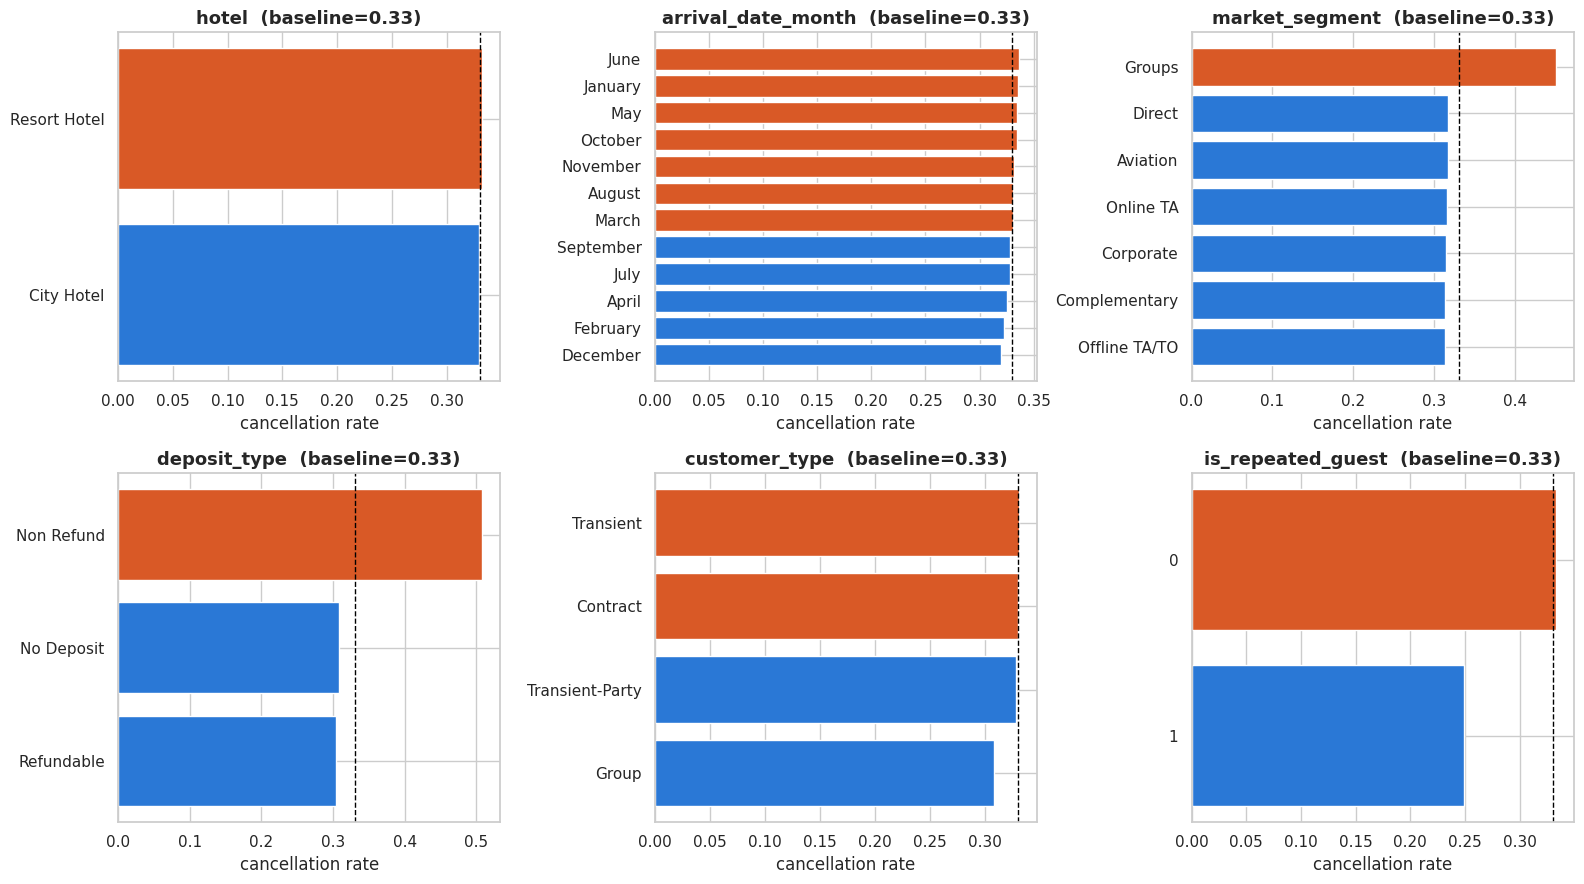

In [12]:
# Cancellation rate by each categorical level, with the global baseline drawn in.
baseline = df[TARGET].mean()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), categorical_cols):
    rates = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    colors = ["#d95926" if r > baseline else "#2a78d6" for r in rates.values]
    ax.barh(rates.index.astype(str), rates.values, color=colors)
    ax.axvline(baseline, color="black", ls="--", lw=1)
    ax.set_title(f"{col}  (baseline={baseline:.2f})")
    ax.set_xlabel("cancellation rate")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Orange bars = above-baseline cancellation (higher risk).** Standouts:
- **Deposit type:** Non-Refund bookings cancel far more than No-Deposit/Refundable — a
  strong, if counter-intuitive, signal (worth investigating; often these are already
  flagged-risky bookings).
- **Market segment:** Groups cancel notably more than Direct/Corporate.
- **Repeated guests** cancel less — loyalty signal.

These high-separation features are prime keepers for modelling.

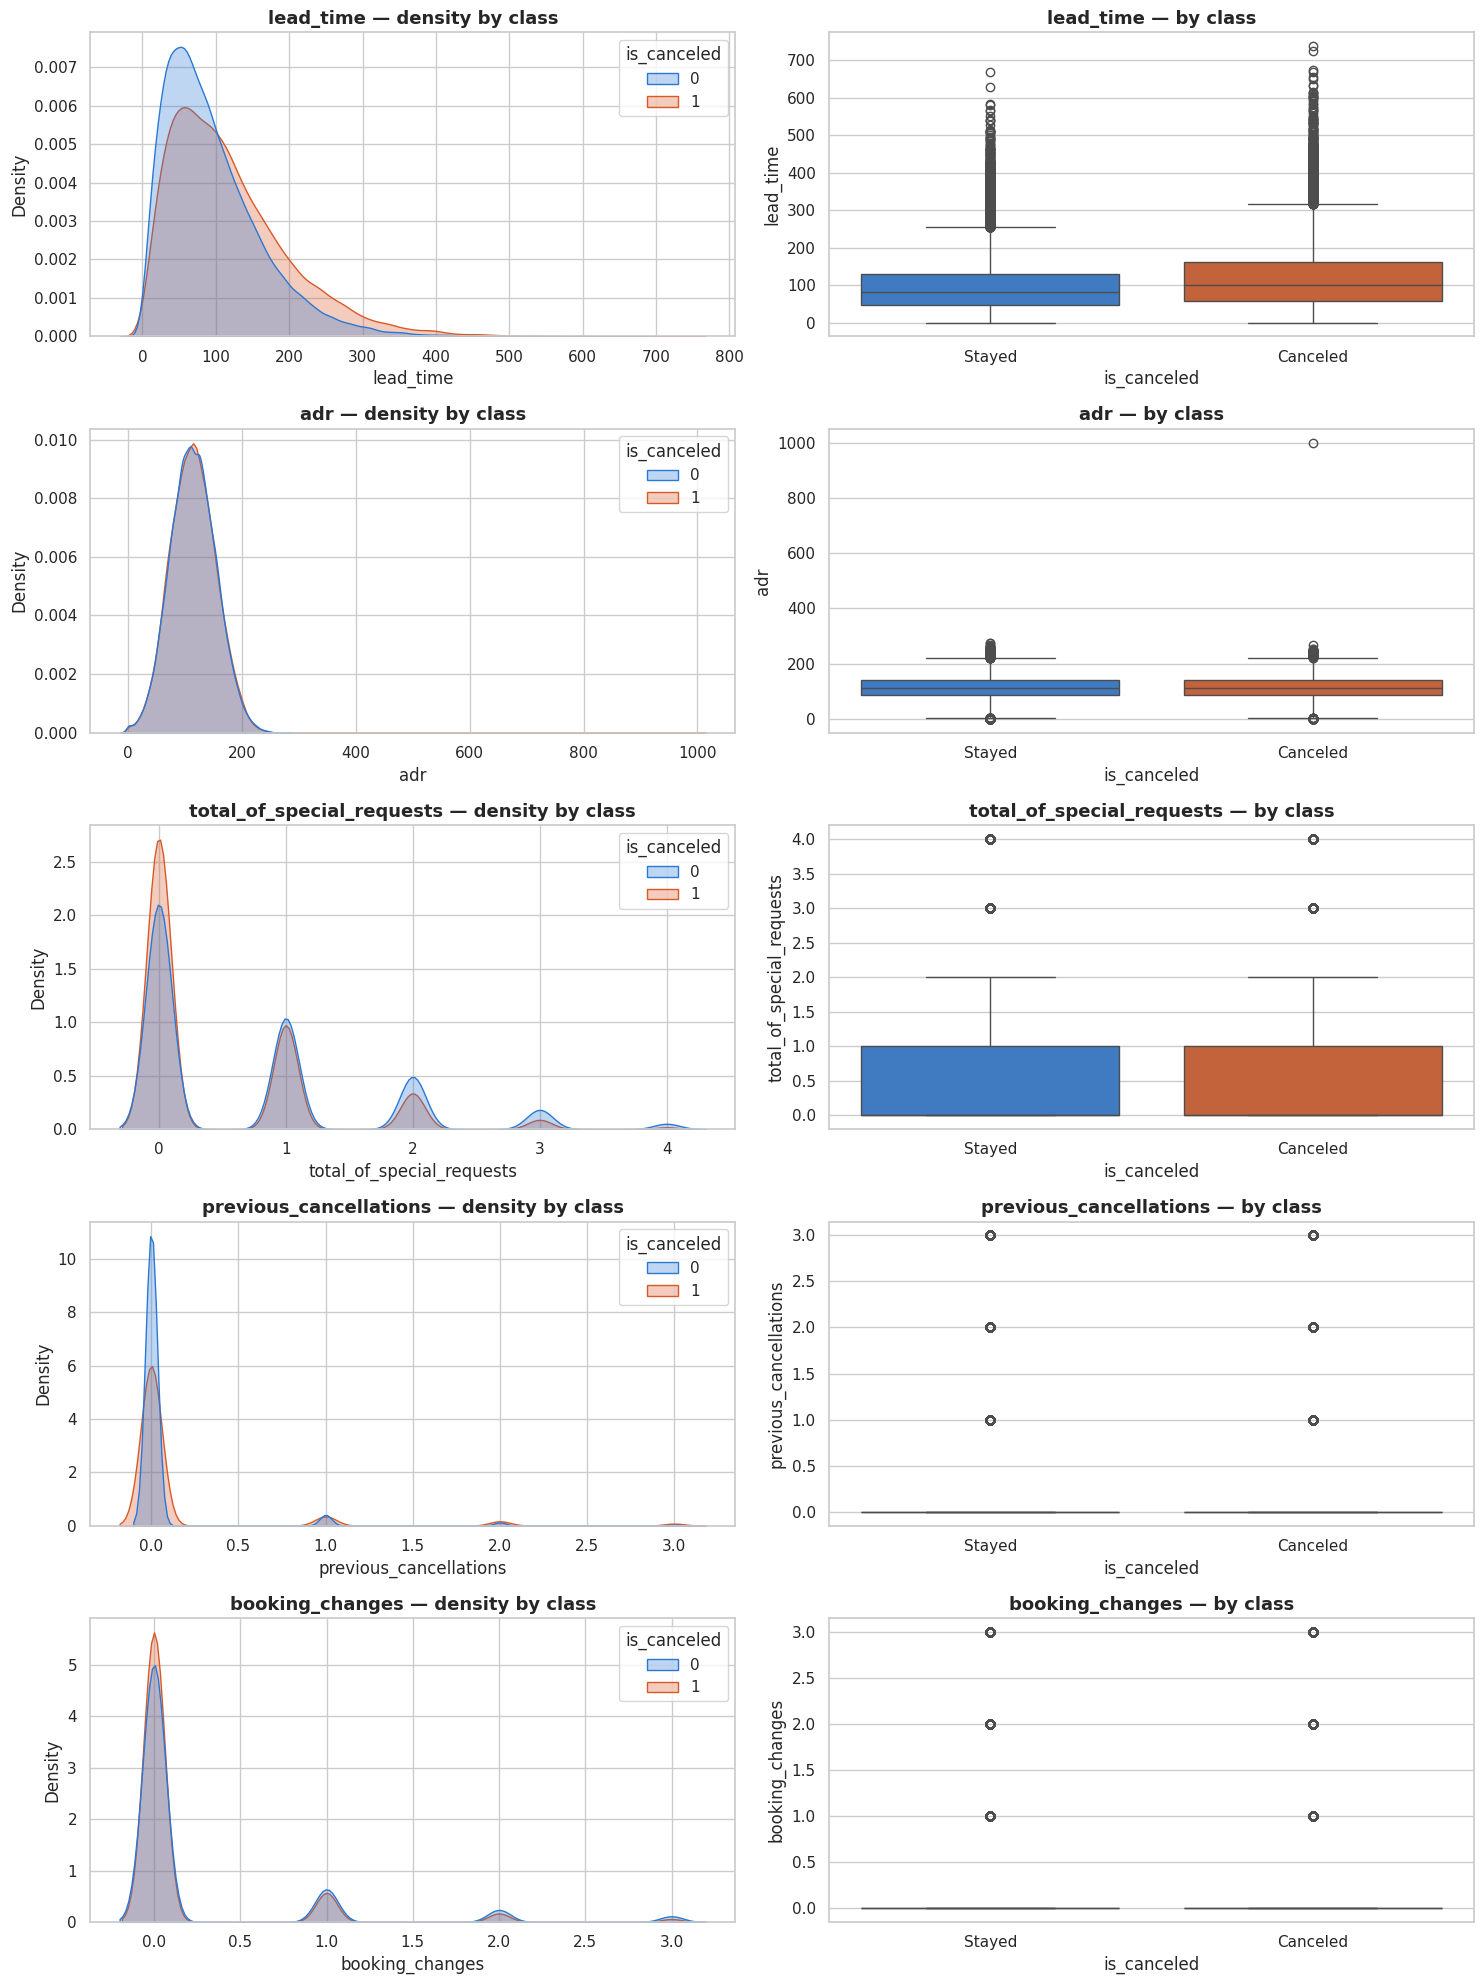

In [13]:
# Numeric features vs target: overlaid distributions + boxplots by class.
key_numeric = ["lead_time", "adr", "total_of_special_requests",
               "previous_cancellations", "booking_changes"]
class_palette = ["#2a78d6", "#d95926"]   # index 0 = stayed, 1 = canceled
fig, axes = plt.subplots(len(key_numeric), 2, figsize=(15, 4 * len(key_numeric)))
for i, col in enumerate(key_numeric):
    sns.kdeplot(data=df, x=col, hue=TARGET, common_norm=False,
                palette=class_palette, ax=axes[i, 0], fill=True, alpha=0.3)
    axes[i, 0].set_title(f"{col} — density by class")
    sns.boxplot(data=df, x=TARGET, y=col, hue=TARGET, legend=False,
                palette=class_palette, ax=axes[i, 1])
    axes[i, 1].set_xticklabels(["Stayed", "Canceled"])
    axes[i, 1].set_title(f"{col} — by class")
plt.tight_layout()
plt.show()

**Reading numeric-vs-target:** cancelled bookings tend to have **longer lead times** and
**fewer special requests** — both intuitive (more time to change plans; less commitment).
`previous_cancellations` shifts higher for cancellers, as expected. These separations
confirm the features carry signal.

In [14]:
# Quantify categorical association with a rate table for the strongest driver.
tab = (df.groupby("deposit_type")[TARGET]
         .agg(cancel_rate="mean", n="count")
         .sort_values("cancel_rate", ascending=False))
tab["lift_vs_baseline"] = (tab["cancel_rate"] / baseline).round(2)
tab.round(3)

,cancel_rate,n,lift_vs_baseline
deposit_type,,,
Non Refund,0.508,10806,1.54
No Deposit,0.308,84640,0.93
Refundable,0.304,1045,0.92


## 6. Multivariate analysis — correlation, redundancy & interactions

**Question:** how do features relate to *each other* (redundancy) and does the effect of
one depend on another (interaction)? Redundant features add noise; interactions are gold
for feature engineering.

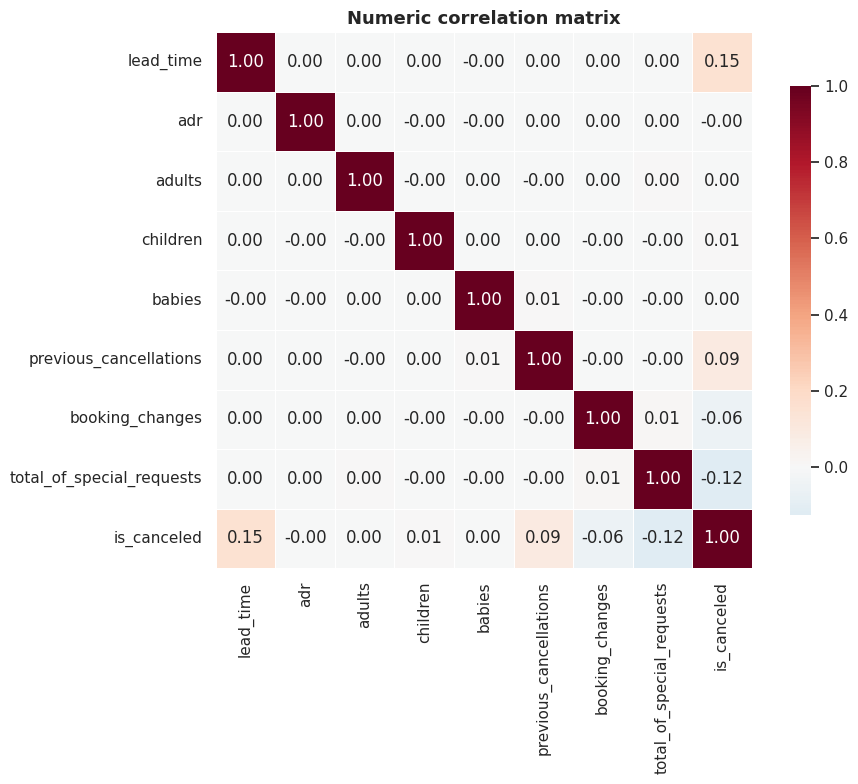

In [15]:
# Correlation heatmap over numeric features (+ target).
corr = df[numeric_cols + [TARGET]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Numeric correlation matrix")
plt.tight_layout()
plt.show()

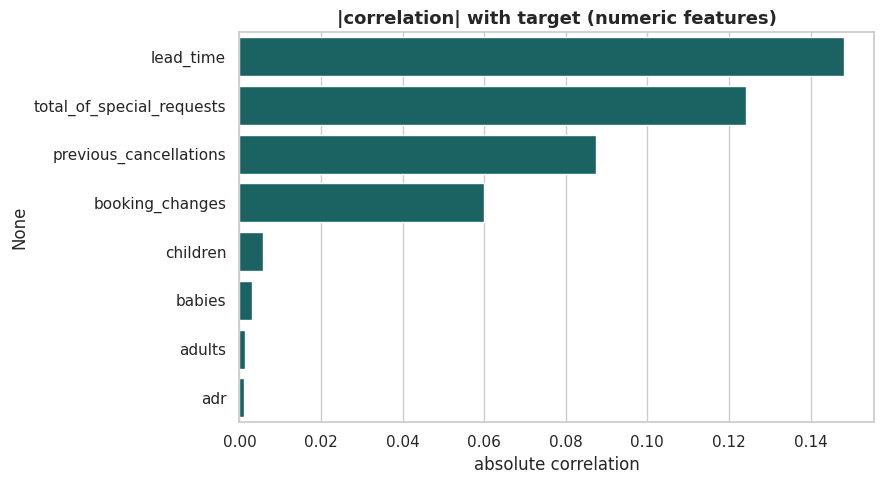

lead_time                    0.148
total_of_special_requests    0.124
previous_cancellations       0.087
booking_changes              0.060
children                     0.006
babies                       0.003
adults                       0.001
adr                          0.001
Name: is_canceled, dtype: float64

In [16]:
# Correlation *with the target*, ranked — a first predictive-power screen.
target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, color=ACCENT)
plt.title("|correlation| with target (numeric features)")
plt.xlabel("absolute correlation")
plt.tight_layout()
plt.show()
target_corr.round(3)

**Reading correlations:** no numeric feature has a very high absolute correlation with the
target (top is `lead_time` at ~0.15). That's **healthy** — it means (a) no single-feature
leakage, and (b) the problem is genuinely multivariate, so tree ensembles that capture
interactions should outperform any single linear signal. Also check off-diagonal cells for
redundant pairs (none are alarmingly high here).

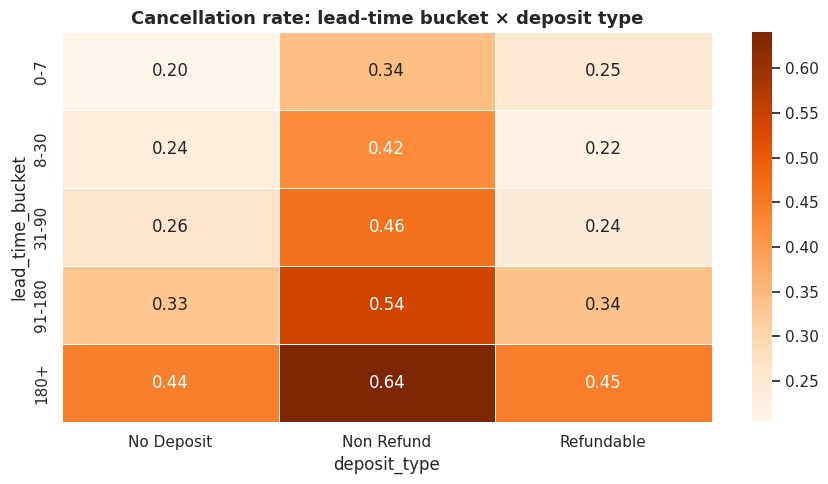

In [17]:
# Interaction example: does lead_time's effect on cancellation depend on deposit_type?
df["lead_time_bucket"] = pd.cut(df["lead_time"],
                                bins=[-1, 7, 30, 90, 180, 10_000],
                                labels=["0-7", "8-30", "31-90", "91-180", "180+"])
pivot = df.pivot_table(index="lead_time_bucket", columns="deposit_type",
                       values=TARGET, aggfunc="mean")
plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Oranges", linewidths=0.5)
plt.title("Cancellation rate: lead-time bucket × deposit type")
plt.tight_layout()
plt.show()

**Interaction insight:** cancellation rate climbs with lead-time bucket, and the climb is
*steeper* within some deposit types than others — evidence of a real **interaction**. This
motivates engineered interaction features (or tree models, which capture these natively) in
Stage 3.

## 7. Temporal & seasonal patterns

**Question:** how do bookings and cancellations move through the calendar? Seasonality
drives the demand-forecasting model later and is a prime source of *data drift*.

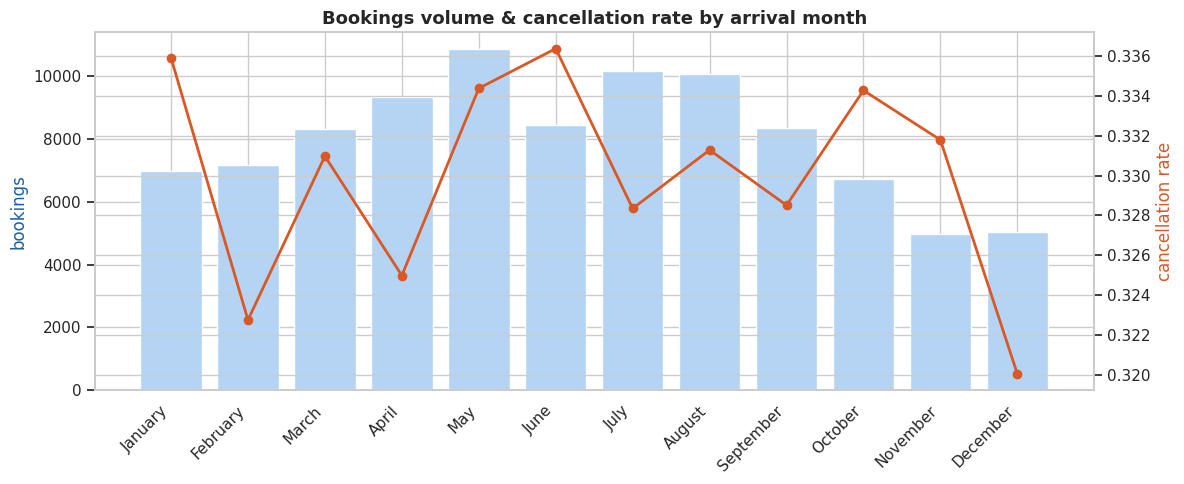

In [18]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"],
                                          categories=month_order, ordered=True)

monthly = df.groupby("arrival_date_month").agg(
    bookings=(TARGET, "size"),
    cancel_rate=(TARGET, "mean"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(monthly["arrival_date_month"], monthly["bookings"],
        color="#b5d4f4", label="bookings")
ax1.set_ylabel("bookings", color="#185fa5")
ax1.set_xticklabels(monthly["arrival_date_month"], rotation=45, ha="right")
ax2 = ax1.twinx()
ax2.plot(monthly["arrival_date_month"], monthly["cancel_rate"],
         color="#d95926", marker="o", lw=2, label="cancel rate")
ax2.set_ylabel("cancellation rate", color="#d95926")
ax1.set_title("Bookings volume & cancellation rate by arrival month")
plt.tight_layout()
plt.show()

**Note on dual axes:** shown here only for a compact seasonal overview; for modelling we'd
keep volume and rate as separate series. Summer months carry the most volume; the
cancellation-rate line reveals whether peak season is also higher-risk — a key input to
both pricing and demand models.

## 8. Outlier deep-dive

**Question:** which extreme values remain, are they errors or real, and how should we treat
them? We use the IQR rule as a screen, then judge case-by-case.

In [19]:
def iqr_outliers(series: pd.Series) -> tuple[int, float, float]:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((series < lo) | (series > hi)).sum())
    return n, lo, hi

print(f"{'feature':<28}{'n_outliers':>12}{'lower':>10}{'upper':>10}")
for col in ["lead_time", "adr", "booking_changes", "total_of_special_requests"]:
    n, lo, hi = iqr_outliers(df[col])
    print(f"{col:<28}{n:>12,}{lo:>10.1f}{hi:>10.1f}")

feature                       n_outliers     lower     upper
lead_time                          2,947     -87.5     276.5
adr                                  569       4.7     221.8
booking_changes                   14,519       0.0       0.0
total_of_special_requests          4,676      -1.5       2.5


In [20]:
# adr outlier inspection — are extreme prices plausible or errors?
top_adr = df.nlargest(10, "adr")[["hotel", "adr", "lead_time", "market_segment",
                                  "deposit_type", TARGET]]
print("Top-10 ADR bookings:")
top_adr

Top-10 ADR bookings:


,hotel,adr,lead_time,market_segment,deposit_type,is_canceled
37001,City Hotel,1000.00,268,Online TA,No Deposit,1
4592,City Hotel,275.39,201,Groups,No Deposit,0
25703,City Hotel,274.56,118,Online TA,No Deposit,0
85890,City Hotel,267.79,91,Offline TA/TO,No Deposit,1
26062,City Hotel,267.22,60,Online TA,No Deposit,0
31924,City Hotel,263.68,178,Online TA,No Deposit,0
12517,City Hotel,263.06,269,Offline TA/TO,No Deposit,0
6328,City Hotel,261.71,16,Offline TA/TO,No Deposit,0
10316,City Hotel,261.57,154,Online TA,No Deposit,0
76032,City Hotel,259.35,93,Direct,No Deposit,0


**Outlier judgement:** IQR flags many `lead_time` and `adr` points, but most are *plausible*
(genuine early bookings, premium rooms), not errors — Stage-1 already handled the impossible
values (negatives, the 5400 spike). We therefore **keep** these as legitimate signal rather
than clipping further; over-aggressive outlier removal would discard real high-risk bookings.

## 9. Systematic leakage hunt

**Question:** is any feature secretly encoding the answer? We already dropped
`reservation_status` (known only *after* the outcome). Here we double-check that nothing
else behaves like a leak.

In [21]:
# Any numeric feature with |corr| > 0.85 to the target is a leakage red flag.
num_corr = df[numeric_cols].corrwith(df[TARGET]).abs().sort_values(ascending=False)
print("Top |correlation| with target:")
print(num_corr.round(3).to_string())

flagged = num_corr[num_corr > 0.85]
print("\nLeakage red flags (|corr| > 0.85):",
      dict(flagged.round(3)) if len(flagged) else "none — clean ✔")

Top |correlation| with target:
lead_time                    0.148
total_of_special_requests    0.124
previous_cancellations       0.087
booking_changes              0.060
children                     0.006
babies                       0.003
adults                       0.001
adr                          0.001

Leakage red flags (|corr| > 0.85): none — clean ✔


In [22]:
# Categorical leakage check: does any single level almost perfectly predict the target?
print("Max single-level cancellation rate per categorical (near 0 or 1 = suspicious):")
for col in categorical_cols:
    rates = df.groupby(col)[TARGET].mean()
    print(f"  {col:<22} min={rates.min():.2f}  max={rates.max():.2f}")

Max single-level cancellation rate per categorical (near 0 or 1 = suspicious):
  hotel                  min=0.33  max=0.33
  arrival_date_month     min=0.32  max=0.34
  market_segment         min=0.31  max=0.45
  deposit_type           min=0.30  max=0.51
  customer_type          min=0.31  max=0.33
  is_repeated_guest      min=0.25  max=0.33


**Leakage verdict:** the top numeric correlation is ~0.15 and no categorical level is
near-deterministic → **no evidence of leakage**. Had `reservation_status` still been
present, it would show a correlation near 1.0 here. The Stage-1 removal is confirmed
effective.

## 10. Segment profiling — *who* cancels?

**Question:** can we describe the high-risk booking in plain language? This is the
narrative an interviewer or stakeholder remembers.

In [23]:
# Build a simple risk profile by crossing the strongest drivers.
profile = (df.groupby(["deposit_type", "market_segment"])[TARGET]
             .agg(cancel_rate="mean", n="count")
             .reset_index())
profile = profile[profile["n"] >= 200].sort_values("cancel_rate", ascending=False)
print("Highest-risk segments (n >= 200):")
profile.head(10).round(3)

Highest-risk segments (n >= 200):


,deposit_type,market_segment,cancel_rate,n
11,Non Refund,Groups,0.602,1241
9,Non Refund,Corporate,0.542,708
13,Non Refund,Online TA,0.497,5102
10,Non Refund,Direct,0.496,1282
12,Non Refund,Offline TA/TO,0.476,2175
4,No Deposit,Groups,0.430,9438
20,Refundable,Online TA,0.296,486
3,No Deposit,Direct,0.295,10065
6,No Deposit,Online TA,0.293,39700
5,No Deposit,Offline TA/TO,0.292,17033


In [24]:
print("Lowest-risk segments (n >= 200):")
profile.tail(10).round(3)

Lowest-risk segments (n >= 200):


,deposit_type,market_segment,cancel_rate,n
10,Non Refund,Direct,0.496,1282
12,Non Refund,Offline TA/TO,0.476,2175
4,No Deposit,Groups,0.430,9438
20,Refundable,Online TA,0.296,486
3,No Deposit,Direct,0.295,10065
6,No Deposit,Online TA,0.293,39700
5,No Deposit,Offline TA/TO,0.292,17033
0,No Deposit,Aviation,0.292,857
1,No Deposit,Complementary,0.290,1637
2,No Deposit,Corporate,0.288,5910


**The story in one line:** the highest-risk booking looks like a *long-lead, group,
non-refundable* reservation with *few special requests*; the safest looks like a
*short-lead, repeated-guest, direct* booking *with* special requests. That narrative will
guide feature engineering and is exactly the kind of insight to lead with in an interview.

## 11. Interactive views (Plotly)

Static charts are best for rigorous, side-by-side comparison; interactive charts shine for
*exploration* — hovering for exact values, filtering, zooming. Below, a few key views are
rendered interactively so a reader can dig in themselves.

In [25]:
import plotly.express as px

# Interactive: cancellation rate by month, hoverable.
monthly_pl = monthly.copy()
monthly_pl["arrival_date_month"] = monthly_pl["arrival_date_month"].astype(str)
fig = px.line(monthly_pl, x="arrival_date_month", y="cancel_rate", markers=True,
              title="Cancellation rate by month (interactive)",
              labels={"cancel_rate": "cancellation rate", "arrival_date_month": "month"})
fig.update_traces(line_color="#d95926")
fig.show()

In [26]:
# Interactive: lead-time distribution split by outcome (hover + zoom).
fig = px.histogram(df, x="lead_time", color=TARGET, nbins=60, barmode="overlay",
                   opacity=0.6, color_discrete_map={0: "#2a78d6", 1: "#d95926"},
                   title="Lead time by outcome (interactive)",
                   labels={"is_canceled": "canceled"})
fig.show()

In [27]:
# Interactive sunburst: booking composition by hotel → deposit → outcome.
df_sb = df.copy()
df_sb["outcome"] = df_sb[TARGET].map({0: "Stayed", 1: "Canceled"})
fig = px.sunburst(df_sb, path=["hotel", "deposit_type", "outcome"],
                  color="outcome",
                  color_discrete_map={"Stayed": "#2a78d6", "Canceled": "#d95926",
                                      "(?)": "#cccccc"},
                  title="Booking composition: hotel → deposit → outcome")
fig.show()

## 12. Insight summary → decisions for Stage 3 (feature engineering)

A good EDA ends not with charts but with **decisions**. Here is the explicit hand-off:

| # | Insight | Decision for feature engineering / modelling |
|---|---------|-----------------------------------------------|
| 1 | Target imbalanced ~2:1 | Use PR-AUC; apply class weights (evaluate SMOTE) |
| 2 | `lead_time` right-skewed | Add log/sqrt transform; also bucket it |
| 3 | Zero-inflated counts (`previous_cancellations`, `booking_changes`, `babies`) | Add binary "has any" flags |
| 4 | Deposit type & market segment strongly separate the target | Keep + encode; likely top features |
| 5 | Repeated guests cancel less | Keep `is_repeated_guest`; consider loyalty features |
| 6 | Lead-time × deposit-type interaction present | Engineer interaction terms; favour tree models |
| 7 | High-cardinality `country`/`agent`/`company` | Target/frequency encoding, not naive one-hot |
| 8 | Strong seasonality by month | Cyclical month encoding; feeds demand model & drift monitoring |
| 9 | No leakage detected | Proceed with confidence; keep the leakage test in CI |
| 10 | Risk profile = long-lead + group + non-refundable + few requests | Build a composite risk feature |

**Next:** Stage 3 turns these decisions into concrete engineered features, with encoding for
the high-cardinality categoricals and the transforms/flags/interactions listed above.